# Week 6 Assessment – Image Denoising using Autoencoder on MNIST

**Project:** Build a deep learning model that removes noise from MNIST digit images using an Autoencoder.

This notebook includes:
- MNIST data loading from uploaded Kaggle ZIP or TensorFlow fallback
- Image preprocessing and normalization
- Noise addition
- Convolutional Autoencoder model
- Model training and validation
- Denoised image visualization
- Evaluation using MSE and PSNR
- Final observations and conclusion

## 1. Import Required Libraries

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Load MNIST Dataset

This code first tries to load MNIST from the uploaded Kaggle ZIP file (`archive.zip`). It automatically uses TensorFlow's built-in MNIST dataset.

In [2]:
ZIP_PATH = "/content/archive.zip"
EXTRACT_PATH = "/content/mnist_data"

def load_mnist_from_png(root_dir, split="training", max_images=None):
    images = []
    labels = []
    split_dir = os.path.join(root_dir, "mnist_png", split)

    for label in sorted(os.listdir(split_dir)):
        label_dir = os.path.join(split_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for file in os.listdir(label_dir):
            if file.lower().endswith(".png"):
                img_path = os.path.join(label_dir, file)
                img = load_img(img_path, color_mode="grayscale", target_size=(28, 28))
                img = img_to_array(img) / 255.0
                images.append(img)
                labels.append(int(label))
                if max_images and len(images) >= max_images:
                    return np.array(images), np.array(labels)

    return np.array(images), np.array(labels)

if os.path.exists(ZIP_PATH):
    print("archive.zip found. Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    x_train, y_train = load_mnist_from_png(EXTRACT_PATH, split="training")
    x_test, y_test = load_mnist_from_png(EXTRACT_PATH, split="testing")
else:
    print("archive.zip not found. Loading MNIST from TensorFlow datasets...")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0
    x_train = np.expand_dims(x_train, axis=-1)
    x_test = np.expand_dims(x_test, axis=-1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

archive.zip not found. Loading MNIST from TensorFlow datasets...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


## 3. Visualize Original Images

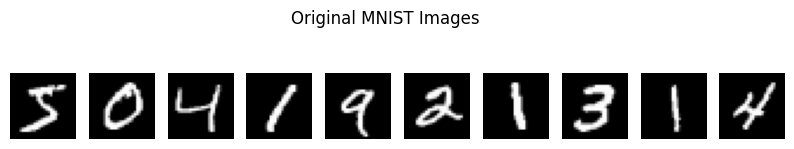

In [3]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Original MNIST Images")
plt.show()

## 4. Add Noise to Images

Random Gaussian noise is added to clean MNIST images. The autoencoder will learn to reconstruct clean images from noisy inputs.

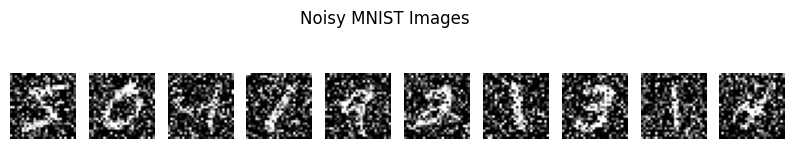

In [4]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
plt.suptitle("Noisy MNIST Images")
plt.show()

## 5. Build Convolutional Autoencoder

The autoencoder has two parts:
- **Encoder:** compresses noisy image into a smaller representation
- **Decoder:** reconstructs the clean image from the compressed representation

In [5]:
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy", metrics=["mse"])

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Autoencoder

In [6]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 213ms/step - loss: 0.1853 - mse: 0.0400 - val_loss: 0.1249 - val_mse: 0.0205
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 102s 217ms/step - loss: 0.1206 - mse: 0.0190 - val_loss: 0.1149 - val_mse: 0.0171
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 210ms/step - loss: 0.1136 - mse: 0.0166 - val_loss: 0.1105 - val_mse: 0.0157
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 207ms/step - loss: 0.1101 - mse: 0.0155 - val_loss: 0.1075 - val_mse: 0.0147
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 210ms/step - loss: 0.1079 - mse: 0.0148 - val_loss: 0.1060 - val_mse: 0.0142
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 212ms/step - loss: 0.1063 - mse: 0.0142 - val_loss: 0.1045 - val_mse: 0.0137
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 215ms/step - loss: 0.1050 - mse: 0.0138 - val_loss: 0.1033 - val_mse: 0.0133
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 215ms/step - loss: 0.1040 - mse: 0.0135 - val_loss: 0.1024 - val_mse: 0.0131
Epoch 9/10
469/469 ━━━━━━

## 7. Plot Training Performance

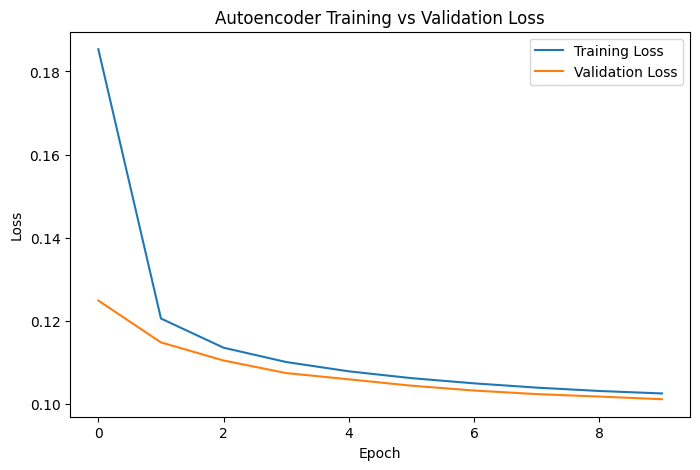

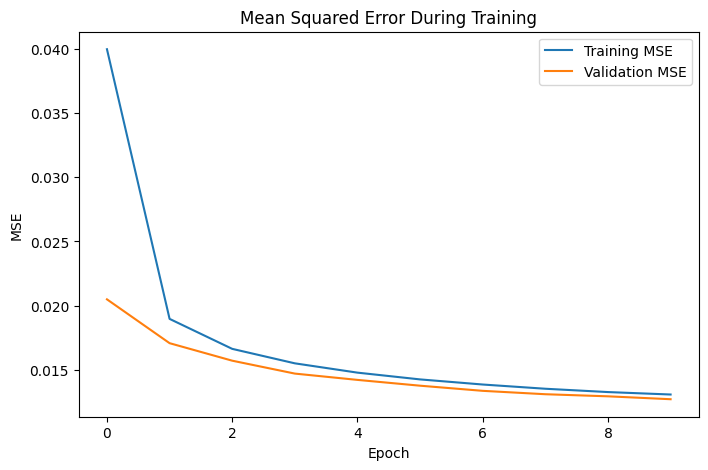

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["mse"], label="Training MSE")
plt.plot(history.history["val_mse"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Mean Squared Error During Training")
plt.legend()
plt.show()

## 8. Generate Denoised Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


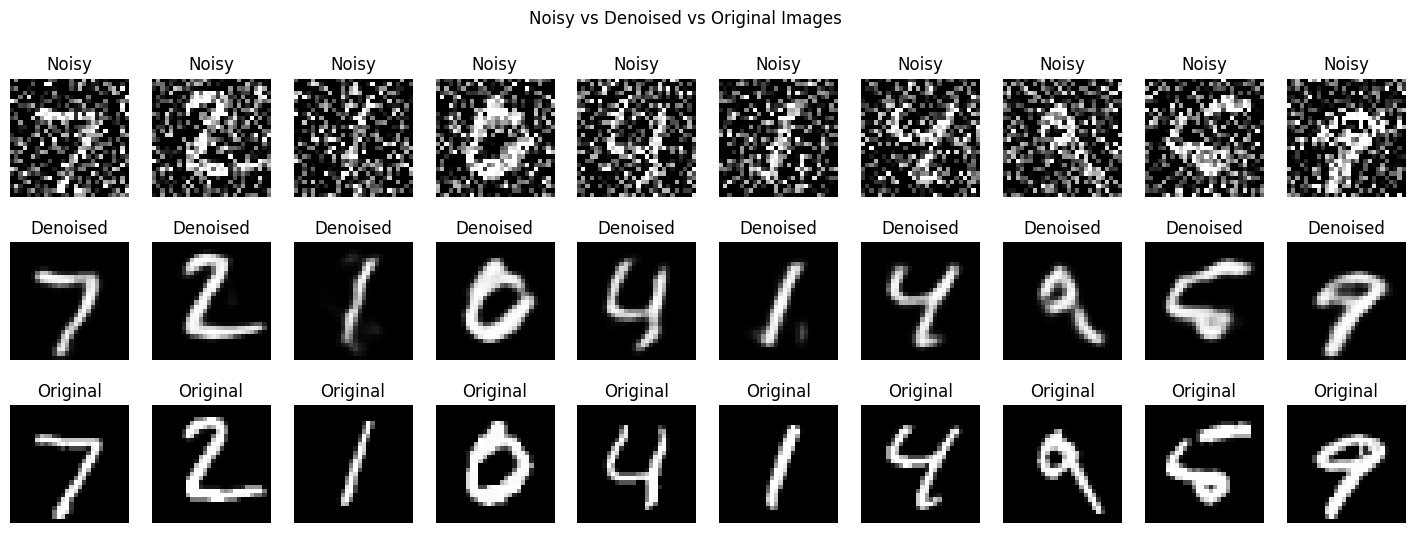

In [8]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(18, 6))
for i in range(n):
    # Noisy image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    # Original image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

plt.suptitle("Noisy vs Denoised vs Original Images")
plt.show()

## 9. Evaluate Denoising Performance

We evaluate using:
- **MSE:** Lower value means better reconstruction
- **PSNR:** Higher value means better image quality

In [9]:
mse_noisy = np.mean((x_test_noisy - x_test) ** 2)
mse_denoised = np.mean((decoded_imgs - x_test) ** 2)

def calculate_psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return 100
    return 20 * np.log10(1.0 / np.sqrt(mse))

psnr_noisy = calculate_psnr(x_test, x_test_noisy)
psnr_denoised = calculate_psnr(x_test, decoded_imgs)

print("MSE before denoising:", mse_noisy)
print("MSE after denoising:", mse_denoised)
print("PSNR before denoising:", psnr_noisy)
print("PSNR after denoising:", psnr_denoised)

MSE before denoising: 0.11546355887404433
MSE after denoising: 0.01269247
PSNR before denoising: 9.375550605950579
PSNR after denoising: 18.964539


## 10. Final Observations

1. The noisy MNIST images contain random pixel-level disturbance, making digits less clear.
2. The convolutional autoencoder learns to reconstruct clean images from noisy inputs.
3. After denoising, digits become more readable and closer to the original images.
4. MSE decreases after denoising, which shows that reconstruction error is reduced.
5. PSNR improves after denoising, indicating better image quality.

## 11. Conclusion

In this Week 6 assessment, I built a deep learning based image denoising model using a convolutional autoencoder on the MNIST dataset. The model was trained using noisy images as input and clean images as target output. After training, the autoencoder successfully reduced noise and reconstructed clearer digit images. This assignment helped me understand autoencoders, encoder-decoder architecture, image reconstruction, and deep learning based denoising.